In [3]:
import pandas as pd #for data framming
import numpy as np #for numarical instruction
import matplotlib.pyplot as plt #for visualisation of data
from sklearn.model_selection import train_test_split 
#to allow our model to split the data according to our model requirmrnts
from sklearn import linear_model #to use logistic regression
from sklearn import metrics 
# to measure model performance (accuracy, confusion matrix).


In [147]:
fp = "Admission_Predict.csv"
# read_csv = used to let our model read all the data of csv file
data =pd.read_csv(fp, sep=",") # sep : saperates all data with ","
data.columns = data.columns.str.strip()  # Removes spaces
data_train, data_test = train_test_split(data, test_size=0.2, random_state=1) 
# rendom state =1 means it will take same data to train and test everytime we run the code
#deviding all data into to training and testing (here it's 20% for testing and 80% for training)

In [148]:
data.shape #to print the size of data in (R, C) formate

(400, 9)

In [149]:
data.head() # to print data of csv file (by default 5 lines with column names)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [152]:
# data_train, data_test = train_test_split(data, test_size =0.3, random_state =1)
data_train.shape #checking how much data is taken for training (r, c) formate

(320, 9)

In [153]:
data_test.shape #checking how much data is taken for testing (r, c) formate

(80, 9)

In [124]:
data_train.info() #info for training data

<class 'pandas.core.frame.DataFrame'>
Index: 280 entries, 39 to 37
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         280 non-null    int64  
 1   GRE Score          280 non-null    int64  
 2   TOEFL Score        280 non-null    int64  
 3   University Rating  280 non-null    int64  
 4   SOP                280 non-null    float64
 5   LOR                280 non-null    float64
 6   CGPA               280 non-null    float64
 7   Research           280 non-null    int64  
 8   Chance             280 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 21.9 KB


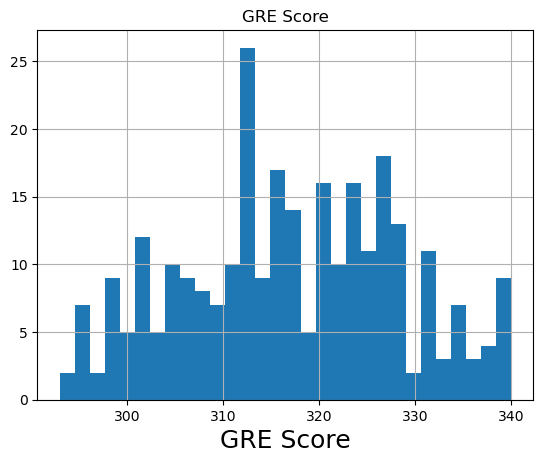

In [125]:
data_train.hist(column = 'GRE Score', bins = 30)
plt.xlabel('GRE Score',fontsize=18)
plt.show()

Text(0, 0.5, 'CGPA')

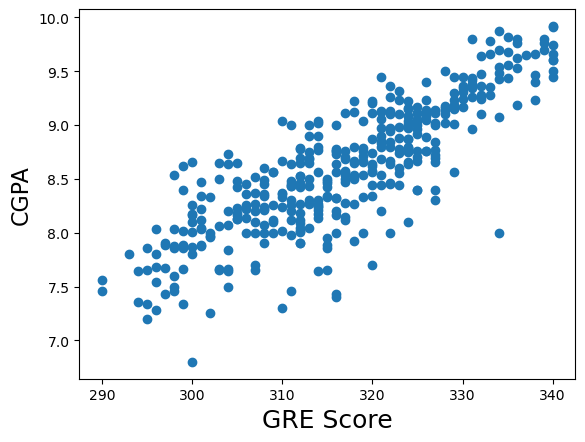

In [126]:
plt.scatter(data['GRE Score'],data['CGPA'])
plt.xlabel('GRE Score', fontsize= 18)
plt.ylabel('CGPA', fontsize = 16)

GRE Score    Axes(0.1,0.15;0.8x0.75)
dtype: object

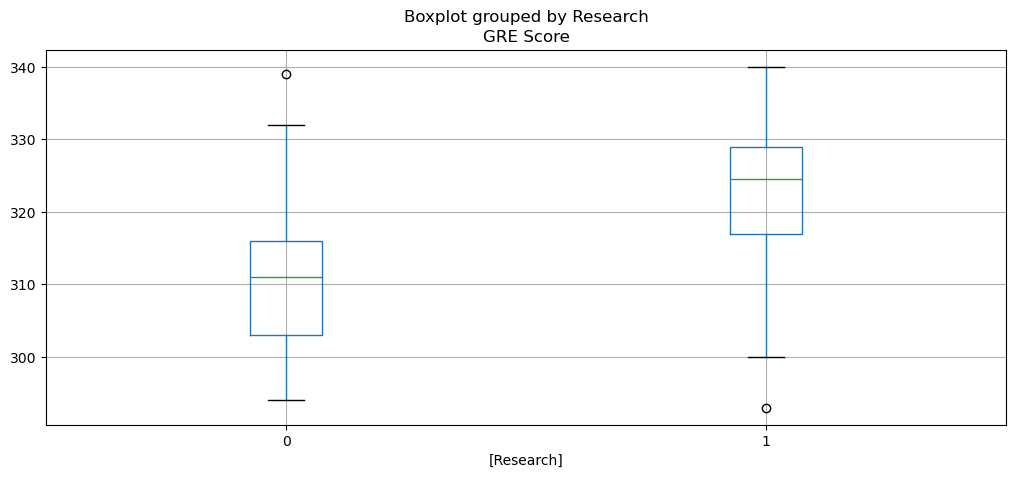

In [127]:
dum = data_train[['Research','GRE Score']]
fig, axes = plt.subplots(ncols = 1, figsize = (12,5), sharey = True)
dum.query("Research in [1,0]").boxplot(by = 'Research',return_type = 'axes', ax=axes)

CGPA    Axes(0.1,0.15;0.8x0.75)
dtype: object

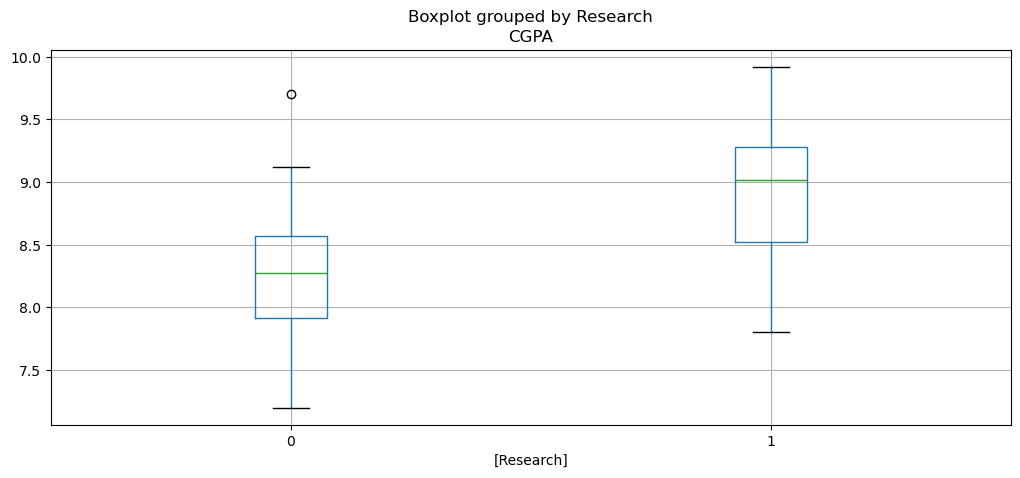

In [128]:
dum = data_train[['Research','CGPA']]
gif, axes = plt.subplots(ncols = 1, figsize = (12,5), sharey = True)
dum.query("Research in [1,0]").boxplot(by = 'Research',return_type = 'axes',ax=axes)

Chance    Axes(0.1,0.15;0.8x0.75)
dtype: object

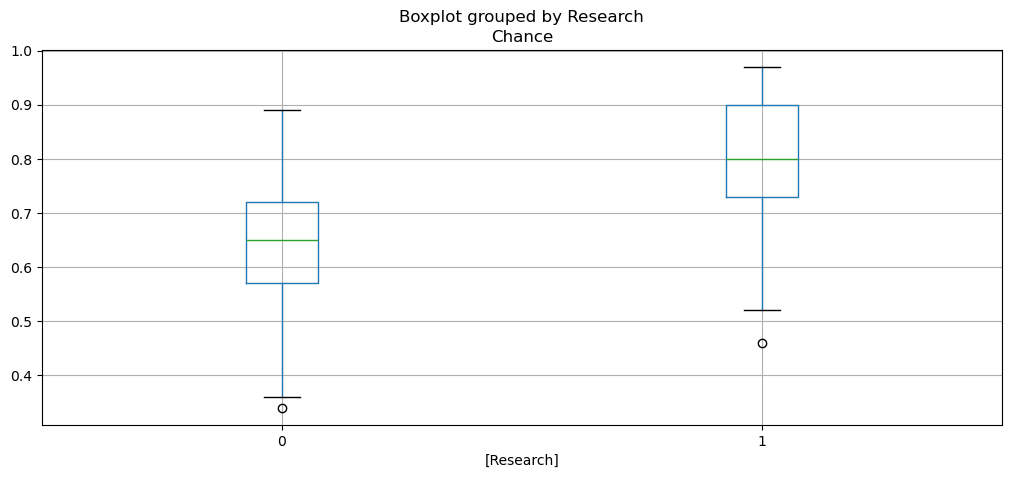

In [129]:
dum = data_train[['Research','Chance']]
gif, axes = plt.subplots(ncols = 1, figsize = (12,5), sharey = True)
dum.query("Research in [1,0]").boxplot(by = 'Research',return_type = 'axes',ax=axes)

In [130]:
data_train.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance
39,40,307,108,2,4.0,3.5,7.70,0,0.48
167,168,313,102,3,2.0,3.0,8.27,0,0.64
383,384,300,100,3,3.0,3.5,8.26,0,0.62
221,222,316,110,3,3.5,4.0,8.56,0,0.75
351,352,325,110,4,3.5,4.0,8.67,1,0.73


In [131]:
x_train = data_train[['GRE Score','TOEFL Score','University Rating','SOP','LOR','CGPA','Chance']]
x_test = data_test[['GRE Score','TOEFL Score','University Rating','SOP','LOR','CGPA','Chance']]

y_train = data_train[["Research"]]
y_test = data_test[["Research"]]

In [132]:
# 'liblinear' → good for small datasets, supports L1 and L2 penalties. Works in a one-vs-rest scheme for multiclass.
# ovr = For multiclass classification, it trains one classifier per class vs. the rest of the classes.
# l1 = This controls the regularization type to avoid overfitting.
# C = 0.1 means strong regularization (simpler model, fewer weights)
LR1 = linear_model.LogisticRegression(random_state = 0, solver = 'liblinear',multi_class = 'ovr',penalty ='l1', C = 0.1)

In [133]:
LR2 = linear_model.LogisticRegression(random_state = 0, solver = 'lbfgs',multi_class = 'ovr',penalty ='l2', C = 0.1)
#'lbfgs' → quasi-Newton optimizer, efficient on larger datasets, supports only L2 penalty.

In [134]:
#Fit the model
LR1.fit(X=x_train, y = y_train)

C:\Users\Krinal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Krinal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Krinal\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LogisticRegression(C=0.1, multi_class='ovr', penalty='l1', random_state=0,
                   solver='liblinear')

In [135]:
LR2.fit(X=x_train,y=y_train)

C:\Users\Krinal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Krinal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Krinal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

LogisticRegression(C=0.1, multi_class='ovr', random_state=0)

In [136]:
#Prediction
y_pred1 = LR1.predict(x_test)
y_pred2 = LR2.predict(x_test)

print (y_pred1)
print (y_pred2)

[1 0 1 1 1 1 0 0 0 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 0
 0 1 0 1 1 1 0 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 0 0 1 1 1 1 0
 1 0 0 1 1 0 0 1 1 1 0 1 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 0 1
 0 1 0 0 1 0 1 1 1]
[0 0 1 1 1 0 0 0 0 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 1 1 0 0
 0 1 1 1 0 1 0 1 1 1 1 0 0 1 0 1 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0
 1 0 0 0 0 0 0 1 0 0 1 0 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1 0 0 0 1 1 1 0 1 1 1
 0 1 0 0 0 0 1 1 1]


In [137]:
#Accuracy
score1 = LR1.score(x_test, y_test)
print(score1)
cm1 = metrics.confusion_matrix(y_test, y_pred1)
print(cm1)

0.6833333333333333
[[29 22]
 [16 53]]


In [138]:
score2 = LR2.score(x_test, y_test)
print(score2)
cm2 = metrics.confusion_matrix(y_test, y_pred2)
print(cm2)

0.8083333333333333
[[40 11]
 [12 57]]


In [139]:
#Naive model

print(np.mean(y_train))
print(1-np.mean(y_test))

0.5357142857142857
0.42500000000000004


In [140]:
#Feature Engineering

data_train['log_gpa'] = np.log(data_train['CGPA'])
data_train['log_gre'] = np.log(data_train['GRE Score'])
data_train['log_toefl'] = np.log(data_train['TOEFL Score'])
data_train['log_lor'] = np.log(data_train['LOR'])
data_train['log_sop'] = np.log(data_train['SOP'])
data_train['log_rank'] = np.log(data_train['University Rating'])

data_test['log_gpa'] = np.log(data_test['CGPA'])
data_test['log_gre'] = np.log(data_test['GRE Score'])
data_test['log_toefl'] = np.log(data_test['TOEFL Score'])
data_test['log_lor'] = np.log(data_test['LOR'])
data_test['log_sop'] =  np.log(data_test['SOP'])
data_test['log_rank'] = np.log(data_test['University Rating'])

x_train = data_train[['log_gpa','log_gre','log_toefl','log_lor','log_sop','log_rank','Chance']]
x_test = data_test[['log_gpa','log_gre','log_toefl','log_lor','log_sop','log_rank','Chance']]

y_train = data_train[["Research"]]
y_test = data_test[["Research"]]

In [141]:
#Fit the models with transformed features
LR1.fit(X=x_train, y=y_train)
LR2.fit(X=x_train, y=y_train)

C:\Users\Krinal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Krinal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Krinal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Krinal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.

LogisticRegression(C=0.1, multi_class='ovr', random_state=0)

In [142]:
#Prediction

y_pred1 = LR1.predict(x_test)

y_pred2 = LR2.predict(x_test)

print (y_pred1)
print (y_pred2)

[1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 0
 0 1 0 1 1 1 0 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 0
 1 0 0 1 1 0 0 1 1 1 0 1 1 1 1 1 0 0 1 1 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1
 0 1 0 1 1 0 1 1 1]
[1 0 1 1 1 0 0 0 0 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 0
 0 1 0 1 1 1 0 1 1 1 1 0 0 1 0 1 1 1 1 0 0 1 1 1 0 1 1 0 1 1 1 0 1 1 0 1 0
 1 0 0 1 1 0 0 1 1 1 1 1 1 1 0 0 0 0 1 1 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1
 0 1 0 0 1 0 1 1 1]


In [143]:
# Accuracy
score1 = LR1.score(x_test, y_test)
print(score1)
cm1 = metrics.confusion_matrix(y_test, y_pred1)
print(cm1)

0.7166666666666667
[[27 24]
 [10 59]]


In [144]:
score2 = LR2.score(x_test, y_test)
print(score2)
cm2 = metrics.confusion_matrix(y_test, y_pred2)
print(cm2)

0.7583333333333333
[[34 17]
 [12 57]]
